# B3 — Table 5 (OOD robustness)

**Produces**: manuscript Table 5 — daily-mean profits on Part A (stress subsets
within the test set) and Part B (synthetic distribution shifts).

- The 4 learned methods × 10 seeds are evaluated in **eval mode, without retraining**.
- MPC rows: Part A = `results/baseline/mpc_daily.json` (nominal daily values
  sliced by subset), Part B = `results/ood_analysis/mpc_partB.json`
  (re-solve cache on perturbed data — rebuild with `code/optimization/mpc_partB.py`).
- Output CSVs: `results/ood_analysis/OOD_Compare_Part{A,B}_mono.csv`
  (the graphical-abstract chart reads these).
- Runtime: about 5-15 min on CPU (440 evaluations).


In [1]:
import os, sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

REV  = os.path.abspath(os.path.join(os.getcwd(), ".."))  # repo root
CODE = os.path.join(REV, "code"); sys.path.insert(0, CODE)
RES  = os.path.join(REV, "results")
ANA  = os.path.join(REV, "analysis")


In [2]:
# Subset / scenario definitions
from data.settings import Data_Test
from algorithms.eval_utils import (METHODS, set_cap_ope, make_envs, find_ckpt,
                                   evaluate_checkpoint, ood_subsets, slice_days,
                                   perturb_data, OOD_SCENARIOS)

DEG, TOL = 5.0, 5.0
SEEDS = range(10)
subsets = ood_subsets(Data_Test)
for nm, idx in subsets.items():
    print(f"{nm:<16} {len(idx):2d} days")


All Test Days    30 days
High Volatility  10 days
Extreme Price    16 days
Low Solar        10 days
High Solar       10 days


In [3]:
# Evaluation loop (method x seed x [subset + scenario])
set_cap_ope(TOL)
partA = {n: {s: [] for s in subsets} for n in METHODS}
partB = {n: {s: [] for s in OOD_SCENARIOS} for n in METHODS}
for name, spec in METHODS.items():
    for seed in SEEDS:
        p = find_ckpt(spec["dirs"], spec["tag"], DEG, TOL, seed)
        if p is None:
            print(f"[skip] {name} seed{seed}"); continue
        for nm, idx in subsets.items():
            env_d, env_s = make_envs(slice_days(Data_Test, idx), TOL, DEG)
            partA[name][nm].append(evaluate_checkpoint(spec["kind"], p, env_d, env_s)[:, 3].mean())
        for nm, kw in OOD_SCENARIOS.items():
            env_d, env_s = make_envs(perturb_data(Data_Test, **kw), TOL, DEG)
            partB[name][nm].append(evaluate_checkpoint(spec["kind"], p, env_d, env_s)[:, 3].mean())
        print(f"[done] {name} seed{seed}", flush=True)


[done] Single-SAC seed0


[done] Single-SAC seed1


[done] Single-SAC seed2


[done] Single-SAC seed3


[done] Single-SAC seed4


...

[done] Coop-DABC seed5


[done] Coop-DABC seed6


[done] Coop-DABC seed7


[done] Coop-DABC seed8


[done] Coop-DABC seed9


In [4]:
# MPC rows (cache)
mpc_daily = np.array(json.load(open(os.path.join(RES, "baseline", "mpc_daily.json"))))
partA["MPC"] = {nm: [float(mpc_daily[idx, 3].mean())] for nm, idx in subsets.items()}
mpc_pB = json.load(open(os.path.join(RES, "ood_analysis", "mpc_partB.json")))
partB["MPC"] = {nm: [float(np.mean(mpc_pB[nm]))] for nm in OOD_SCENARIOS if nm in mpc_pB}
print("MPC Part A:", {k: round(v[0]) for k, v in partA["MPC"].items()})
print("MPC Part B:", {k: round(v[0]) for k, v in partB["MPC"].items()})


MPC Part A: {'All Test Days': 4456, 'High Volatility': 4129, 'Extreme Price': 5764, 'Low Solar': 4102, 'High Solar': 4998}
MPC Part B: {'Nominal': 4456, 'Price -20%': 3509, 'Price +20%': 5513, 'Volatility x1.5': 5316, 'Price noise 10%': 3982, 'Solar noise 10%': 4479}


In [5]:
# Assemble Table 5 + save CSVs
def agg_df(part, key):
    return pd.DataFrame([{key: nm, "Method": a, "n_seeds": len(v),
                          "mean": round(np.mean(v), 1), "std": round(np.std(v), 1)}
                         for a in part for nm, v in part[a].items() if v])

dfA, dfB = agg_df(partA, "Subset"), agg_df(partB, "Scenario")
OUT = os.path.join(RES, "ood_analysis")
dfA.to_csv(os.path.join(OUT, "OOD_Compare_PartA_mono.csv"), index=False)
dfB.to_csv(os.path.join(OUT, "OOD_Compare_PartB_mono.csv"), index=False)

t5A = dfA.pivot(index="Subset", columns="Method", values="mean").reindex(list(subsets))
t5B = dfB.pivot(index="Scenario", columns="Method", values="mean").reindex(list(OOD_SCENARIOS))
table5 = pd.concat([t5A, t5B], keys=["Part A — stress subsets", "Part B — distribution shift"])
cols = ["Single-SAC", "Inde-DASAC", "Coop-DASAC", "Coop-DABC", "MPC"]
table5 = table5[[c for c in cols if c in table5.columns]].round(0)
table5


Method                                       Single-SAC  Inde-DASAC  \
Part A — stress subsets     All Test Days        4261.0      4455.0   
                            High Volatility      3930.0      4302.0   
                            Extreme Price        5440.0      5578.0   
                            Low Solar            4000.0      4309.0   
                            High Solar           4743.0      4930.0   
Part B — distribution shift Nominal              4261.0      4455.0   
                            Price -20%           3380.0      3537.0   
                            Price +20%           5144.0      5371.0   
                            Volatility x1.5      5017.0      5311.0   
                            Price noise 10%      4265.0      4460.0   
                            Solar noise 10%      4289.0      4483.0   

Method                                       Coop-DASAC  Coop-DABC     MPC  
Part A — stress subsets     All Test Days        4566.0     4707.0  4456.0  
                            High Volatility      4515.0     4447.0  4129.0  
                            Extreme Price        5613.0     6024.0  5764.0  
                            Low Solar            4486.0     4454.0  4102.0  
                            High Solar           4969.0     5253.0  4998.0  
Part B — distribution shift Nominal              4566.0     4707.0  4456.0  
                            Price -20%           3630.0     3612.0  3509.0  
                            Price +20%           5497.0     5760.0  5513.0  
                            Volatility x1.5      5478.0     5761.0  5316.0  
                            Price noise 10%      4571.0     4702.0  3982.0  
                            Solar noise 10%      4594.0     4737.0  4479.0

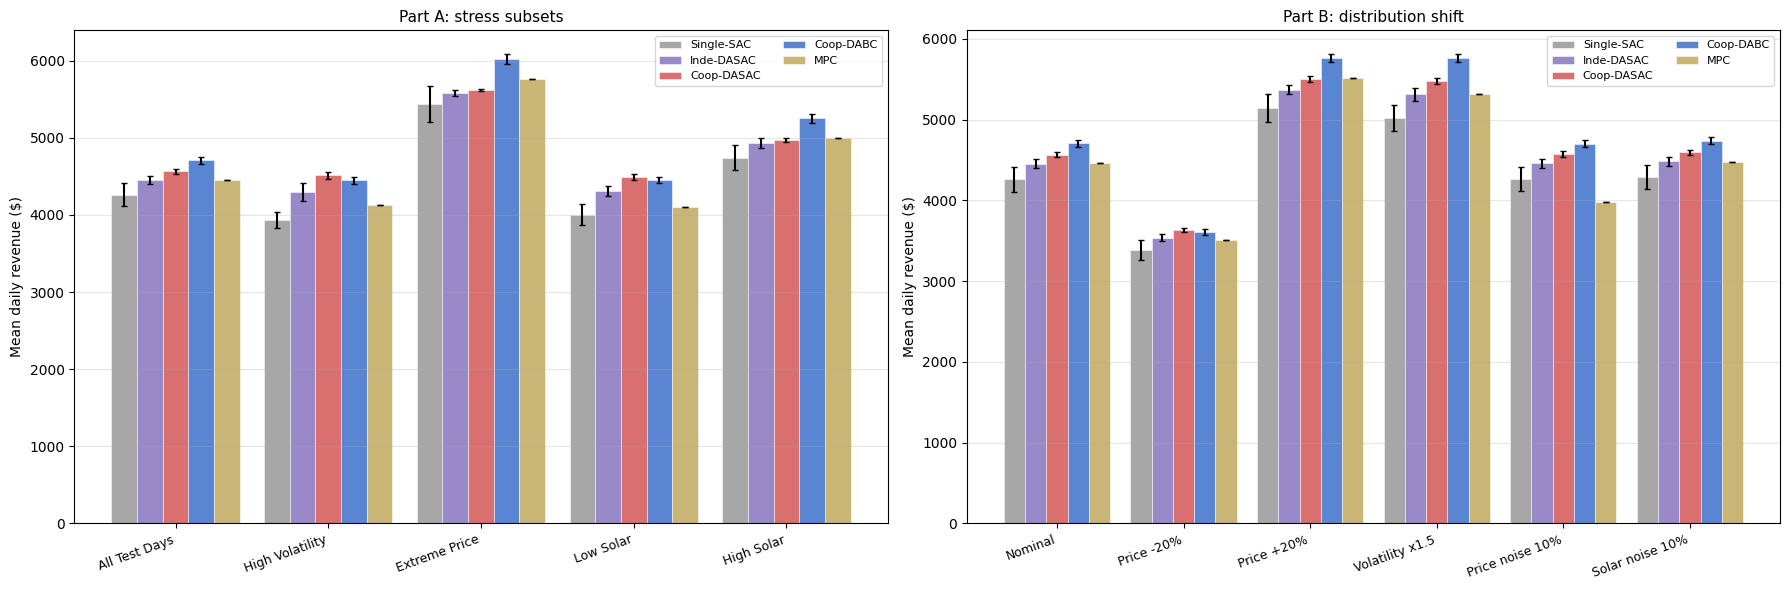

In [6]:
# Plot: grouped bars (RL: 10 seeds +/- std, MPC: deterministic)
COLORS = {"Single-SAC": "#9E9E9E", "Inde-DASAC": "#8E7CC3", "Coop-DASAC": "#D65F5F",
          "Coop-DABC": "#4878CF", "MPC": "#C4AD66"}
def grouped(ax, names, part, title):
    x = np.arange(len(names)); ms = [m for m in COLORS if m in part]; w = 0.84 / len(ms)
    for i, m in enumerate(ms):
        mean = [np.mean(part[m][nm]) if part[m].get(nm) else np.nan for nm in names]
        std  = [np.std(part[m][nm]) if part[m].get(nm) else 0 for nm in names]
        ax.bar(x + (i - (len(ms) - 1) / 2) * w, mean, w, yerr=std, capsize=2,
               label=m, color=COLORS[m], alpha=0.9, edgecolor="white", linewidth=0.4)
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Mean daily revenue ($)"); ax.set_title(title, fontsize=11)
    ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=8, ncol=2)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
grouped(ax[0], list(subsets), partA, "Part A: stress subsets")
grouped(ax[1], list(OOD_SCENARIOS), partB, "Part B: distribution shift")
plt.tight_layout()
plt.savefig(os.path.join(RES, "ood_analysis", "OOD_Compare_AllMethods_mono.png"),
            dpi=150, bbox_inches="tight")
plt.show()
